In [1]:
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=True)

repository = scarf.cytebase.connect("scarf_docs")
ctrl_path = repository.download_dataset(
    name="kang_15K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
stim_path = repository.download_dataset(
    name="kang_14K_ifnb-pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds_ctrl = scarf.DataStore(
    f"{ctrl_path}/data.zarr",
    nthreads=4,
    zarr_mode="r+",
)
ds_stim = scarf.DataStore(
    f"{stim_path}/data.zarr",
    nthreads=4,
    zarr_mode="r+",
)

Downloading bucket files: 40169307 / 40169307 complete

Downloading bytes: 40169307 / 40169307 complete

Downloading bucket files: 46151508 / 46151508 complete

Downloading bytes: 46151508 / 46151508 complete

In [2]:
ds_ctrl.cells.insert(
    "reference_batch",
    np.repeat("control", ds_ctrl.cells.N),
    overwrite=True,
)

In [3]:
normalized = ds_ctrl.run_normalization(feat_key="hvgs")
pca = ds_ctrl.run_pca(normalized, dims=25, feat_scaling=True)
corrected = ds_ctrl.run_harmony(["reference_batch"], pca)
ann_index = ds_ctrl.build_ann_index(corrected)
neighbors = ds_ctrl.query_neighbors(ann_index, k=17)
reference = ds_ctrl.build_mapping_reference(neighbors)
reference

Loading uncorrected latent dimensions: 1 / 1 complete

Harmonizing batches: 50 / 50 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

MappingReference(datastore=DataStore has 8486 (8487) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_percentMito', 'cluster_labels', 
            'RNA_nFeatures', 'RNA_clusters', 'RNA_leiden_cluster', 'RNA_nCounts', 'reference_batch', 
            'RNA_UMAP2', 'RNA_UMAP1', 'RNA_percentRibo'
   RNA assay has 10683 (35635) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'dropOuts', 
            'I__hvgs', ref=ArtifactRef(assay='RNA', kind='mapping_reference', artifact_id='f728bb6b7f14...'), assay_name='RNA', cell_key='I', feature_key='hvgs', reduction=ArtifactRef(assay='RNA', kind='reduction', artifact_id='fcca45ea14c6...'), ann_index=ArtifactRef(assay='RNA', kind='ann_index', artifact_id='81dedb3280d4...'), neighbors=ArtifactRef(assay='RNA', kind='neighbors', artifact_id='9e5a5090f7b5...'), cell_selection=ArtifactRef(datastore, kind='cell_selection', artifact_id='2a06899fbcca...'), feature_selection=ArtifactRef(assay='RNA', ki

In [4]:
reference = ds_ctrl.get_mapping_reference(reference.ref)

In [5]:
query_batches = pd.DataFrame(
    {
        "reference_batch": np.repeat(
            "stimulated",
            len(ds_stim.cells.fetch("ids", key="I")),
        )
    }
)
mapping = ds_stim.run_mapping(
    reference,
    "stim_atlas",
    query_assay="RNA",
    save_k=5,
    query_batches=query_batches,
)
mapping

MappingResult(ref=ArtifactRef(assay='RNA', kind='projection', artifact_id='21d08f49e756...'), mapping_name='stim_atlas', n_cells=10111, correction_method='symphony', diagnostics={'featureCoverage': 1.0, 'queryBatchCount': 1, 'algorithmVariant': 'symphony', 'zeroNormCellCount': 0, 'queryScaledDispersion': 1.2273312252910447}, arrays=not loaded)

In [6]:
mapped = ds_stim.get_mapping_result(
    "stim_atlas",
    reference=reference,
    query_assay="RNA",
    load_arrays=True,
)
mapped.diagnostics

{'featureCoverage': 1.0,
 'queryBatchCount': 1,
 'algorithmVariant': 'symphony',
 'zeroNormCellCount': 0,
 'queryScaledDispersion': 1.2273312252910447}

In [7]:
transferred = ds_stim.get_target_classes(
    mapped,
    reference_class_group="cluster_labels",
    threshold_fraction=0.6,
)
ds_stim.cells.insert(
    "atlas_labels",
    transferred.to_numpy(),
    overwrite=True,
)

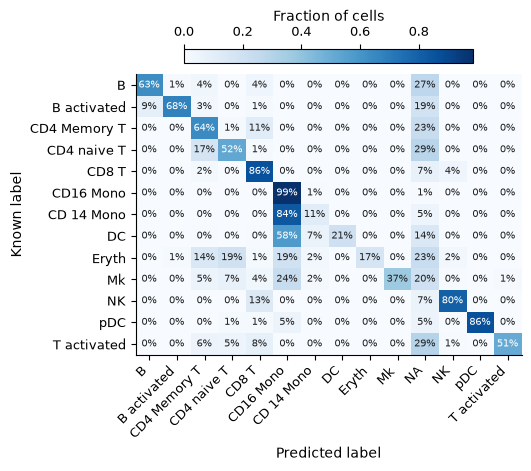

In [8]:
ds_stim.plots.mapping_confusion(
    mapped,
    reference_class_group="cluster_labels",
    known_labels=ds_stim.cells.fetch("cluster_labels"),
    normalize="true",
    threshold_fraction=0.6,
)

In [9]:
projected_embedding = ds_stim.project_reference_embedding(
    mapped,
    reference_layout_key="RNA_UMAP",
    label="atlas_UMAP",
)
projected_embedding

ArtifactRef(assay='RNA', kind='embedding', artifact_id='0ccdd17c5ec8...')

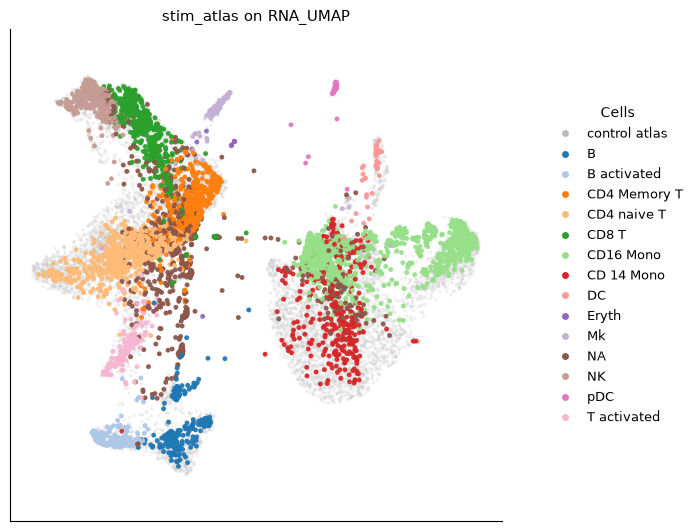

In [10]:
ds_stim.plots.mapping_projection(
    mapped,
    reference_layout_key="RNA_UMAP",
    target_groups=transferred.to_numpy(),
    ref_name="control atlas",
    reference_mode="background",
    figsize=(7.2, 5.2),
)